In [0]:
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import kneighbors_graph
import matplotlib.pyplot as plt
import time
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import seaborn as sns
import numpy as np
import pandas as pd
from itertools import combinations
from scipy.stats import ttest_ind
from sklearn.covariance import MinCovDet
import scipy as sp
from scipy.stats import chi2
from scipy.stats import norm
from sklearn.metrics import r2_score

In [0]:
basin = "GULF COAST EAST"
min_completion_year = 2015
query = f"""select API10, API14, tcaID, primary_phase,wellStatus,OperatorGold,
CompletionYear,LateralLength_FT,Proppant_LBSPerFT,
Fluid_BBLPerFT,oil_eur_mbo,gas_eur_mmcf_ft, 
BoundingAnyZoneAtDrill, ParentChildAnyZone , SpacingHzAnyZoneAtDrill
from produced.analog_well_selection 
where BasinQuantum='{basin}' and wellStatus= 'PRODUCING' and CompletionYear >='{min_completion_year}' """

df = spark.sql(query).toPandas()

/databricks/spark/python/pyspark/sql/pandas/utils.py:109: UserWarning: The conversion of DecimalType columns is inefficient and may take a long time. Column names: [LateralLength_FT, Proppant_LBSPerFT, Fluid_BBLPerFT, oil_eur_mbo, gas_eur_mmcf_ft, SpacingHzAnyZoneAtDrill] If those columns are not necessary, you may consider dropping them or converting to primitive types before the conversion.
  warnings.warn(


In [0]:
#df[df.CompletionYear>=2019].CompletionYear.value_counts()
df.CompletionYear.value_counts()

2022    561
2023    490
2021    479
2019    410
2018    391
2020    389
2017    276
2015    175
2016    157
2024     61
Name: CompletionYear, dtype: int64

In [0]:
df.display()

API10,API14,tcaID,primary_phase,wellStatus,OperatorGold,CompletionYear,LateralLength_FT,Proppant_LBSPerFT,Fluid_BBLPerFT,oil_eur_mbo,gas_eur_mmcf_ft,BoundingAnyZoneAtDrill,ParentChildAnyZone,SpacingHzAnyZoneAtDrill
1701736475,17017364750000,HAYNESVILLE_TCA_HSVL_LA CORE_DE SOTO WEST,GAS,PRODUCING,PALOMA,2021,9885.000000,null,102.155505,0.000000,1.821880,HALF-BOUND,SIBLING,923.20
1708121498,17081214980000,HAYNESVILLE_TCA_HSVL_LA EAST_SOUTH,GAS,PRODUCING,CHK,2016,4733.000000,3391.887000,80.615000,0.000000,1.134854,FULLY-BOUND,CHILD,1289.40
4240530632,42405306320001,HAYNESVILLE_TCA_HSVL_TX DEEP_ SOUTH,GAS,PRODUCING,EXXON,2020,8288.000000,2256.358108,89.461157,0.000000,1.032476,HALF-BOUND,CHILD,1133.14
4240530766,42405307660000,HAYNESVILLE_TCA_HSVL_TX DEEP_ SOUTH,null,PRODUCING,AETHON,2023,10490.000000,5960.967493,131.397712,null,null,HALF-BOUND,SIBLING,908.19
1708121535,17081215350000,HAYNESVILLE_TCA_HSVL_LA EAST_SOUTH,GAS,PRODUCING,CHK,2017,4822.000000,3618.888000,73.105000,0.000000,1.527043,FULLY-BOUND,CHILD,1100.15
4240530582,42405305820000,HAYNESVILLE_TCA_HSVL_TX DEEP_ SOUTH,GAS,PRODUCING,EXXON,2018,6163.000000,1708.979000,null,0.002996,1.438406,FULLY-BOUND,CHILD,1302.10
1701736171,17017361710000,HAYNESVILLE_TCA_HSVL_LA CORE_CADDO SOUTH,GAS,PRODUCING,CHK,2018,9970.000000,3335.652056,68.225529,0.000000,1.708304,FULLY-BOUND,CHILD,985.27
4236538447,42365384470000,HAYNESVILLE_TCA_HSVL_TX EAST_CORE D HIGH BTU,GAS,PRODUCING,TGNR,2019,7515.000000,3513.000000,97.603000,2.080018,0.949657,FULLY-BOUND,SIBLING,793.29
1703126356,17031263560000,HAYNESVILLE_TCA_HSVL_LA CORE_DE SOTO WEST,GAS,PRODUCING,SWN,2017,8359.000000,null,71.940974,0.000000,1.243746,FULLY-BOUND,SIBLING,875.81
4236538819,42365388190100,HAYNESVILLE_TCA_HSVL_TX EAST_CORE A STATELINE,GAS,PRODUCING,ROCKCLIFF,2023,11727.316442,3335.121738,85.581727,0.000000,0.907919,null,null,null


In [0]:
df.groupby('tcaID')["API10", "API14"].nunique().add_prefix('num_').reset_index()

/root/.ipykernel/1579/command-1395104717220544-3035096101:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  df.groupby('tcaID')["API10", "API14"].nunique().add_prefix('num_').reset_index()


,tcaID,num_API10,num_API14
0,BOSSIER_TCA_HSVL_LA NFZ_NATCHITOCHES,48,52
1,BOSSIER_TCA_HSVL_LA NFZ_SABINE,63,65
2,BOSSIER_TCA_HSVL_LA SOUTH_SABINE,70,79
3,BOSSIER_TCA_HSVL_TX DEEP_ SOUTH,75,78
4,HAYNESVILLE_TCA_HSVL_LA CORE_CADDO SOUTH,181,192
5,HAYNESVILLE_TCA_HSVL_LA CORE_DE SOTO EAST,217,231
6,HAYNESVILLE_TCA_HSVL_LA CORE_DE SOTO WEST,488,511
7,HAYNESVILLE_TCA_HSVL_LA EAST_NORTH,126,140
8,HAYNESVILLE_TCA_HSVL_LA EAST_SOUTH,503,522
9,HAYNESVILLE_TCA_HSVL_LA NFZ_NATCHITOCHES,53,59


In [0]:
df_store = df.copy(deep=True)
tca = 'HAYNESVILLE_TCA_HSVL_LA EAST_SOUTH'
df = df_store[df_store['tcaID']==tca]

In [0]:
for year1, year2 in combinations(sorted(df[df.CompletionYear>=2019]['CompletionYear'].unique()), 2):
    print(year1, year2)

2019 2020
2019 2021
2019 2022
2019 2023
2019 2024
2020 2021
2020 2022
2020 2023
2020 2024
2021 2022
2021 2023
2021 2024
2022 2023
2022 2024
2023 2024


In [0]:
reference_year = df['CompletionYear'].max()-1
reference_year

2023

In [0]:
numerical_cols = ["CompletionYear","LateralLength_FT","Proppant_LBSPerFT","Fluid_BBLPerFT", "SpacingHzAnyZoneAtDrill"] # add test 
for col in numerical_cols:
    df[col] = pd.to_numeric(df[col])

/root/.ipykernel/1579/command-2436934722941111-1309187262:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd.to_numeric(df[col])


# t-test 1

In [0]:
import pandas as pd
from itertools import combinations
from scipy.stats import ttest_ind

def pairwise_t_tests(df, features, reference_year):
    similar_years = []
    for feature in features:
        #for year1, year2 in combinations(sorted(df[df['CompletionYear'] >= 2019]['CompletionYear'].unique()), 2):
        for year1, year2 in combinations(sorted(df['CompletionYear'].unique()), 2):
            if year1 == reference_year or year2 == reference_year:
                data_year1 = pd.to_numeric(df[df['CompletionYear'] == year1][feature], errors='coerce').dropna()
                data_year2 = pd.to_numeric(df[df['CompletionYear'] == year2][feature], errors='coerce').dropna()

                if len(data_year1) > 0 and len(data_year2) > 0:  # Check for non-empty data
                    t_statistic, p_value = ttest_ind(data_year1, data_year2)
                    print("T-test p-value:", p_value, feature, year1, year2)
                    if p_value > 0.01:  # If no significant difference found
                        similar_years.append((year1, year2))
    return similar_years

# Usage
numerical_features = ["LateralLength_FT"]#, "Fluid_BBLPerFT", "SpacingHzAnyZoneAtDrill"] # ONLY FOR propant
similar_years = pairwise_t_tests(df, numerical_features, reference_year)
print("Similar years:", similar_years)


T-test p-value: 4.6116455913072473e-14 LateralLength_FT 2015 2023
T-test p-value: 1.673796017913162e-13 LateralLength_FT 2016 2023
T-test p-value: 3.714904757441865e-18 LateralLength_FT 2017 2023
T-test p-value: 1.212147636537147e-06 LateralLength_FT 2018 2023
T-test p-value: 3.31144691399162e-07 LateralLength_FT 2019 2023
T-test p-value: 1.2644316265332196e-05 LateralLength_FT 2020 2023
T-test p-value: 0.006593891345249037 LateralLength_FT 2021 2023
T-test p-value: 0.14077751436192676 LateralLength_FT 2022 2023
T-test p-value: 0.16042169534766645 LateralLength_FT 2023 2024
Similar years: [(2022, 2023), (2023, 2024)]


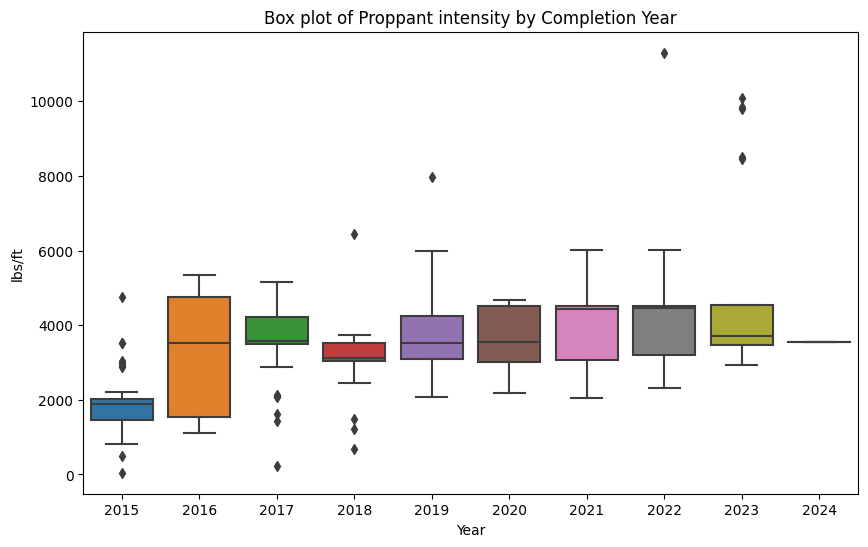

In [0]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(x='CompletionYear', y='Proppant_LBSPerFT', data=df)

plt.title('Box plot of Proppant intensity by Completion Year')
plt.xlabel('Year')
plt.ylabel('lbs/ft')
plt.show()


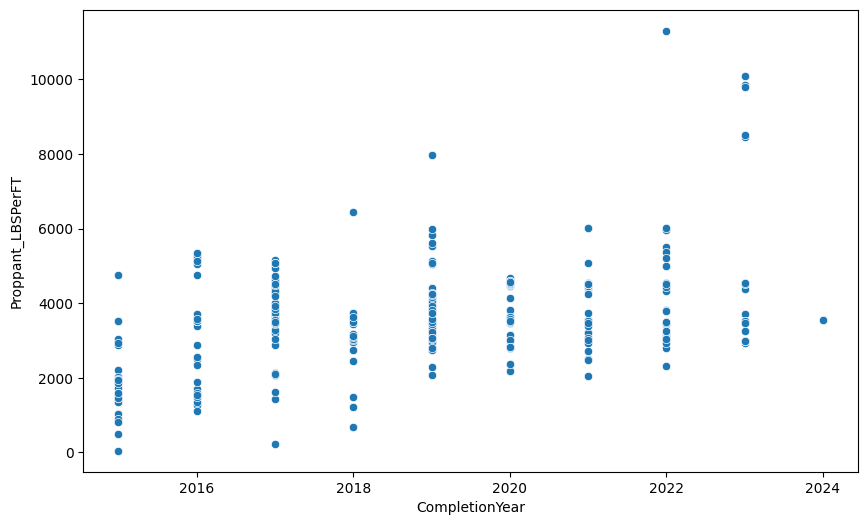

In [0]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='CompletionYear', y='Proppant_LBSPerFT', data=df)
plt.show()

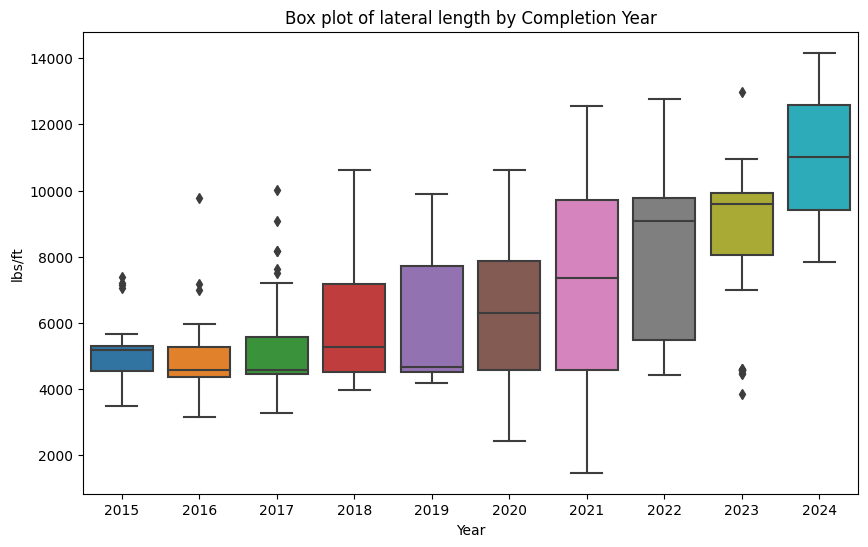

In [0]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(x='CompletionYear', y='LateralLength_FT', data=df)

plt.title('Box plot of lateral length by Completion Year')
plt.xlabel('Year')
plt.ylabel('lbs/ft')
plt.show()

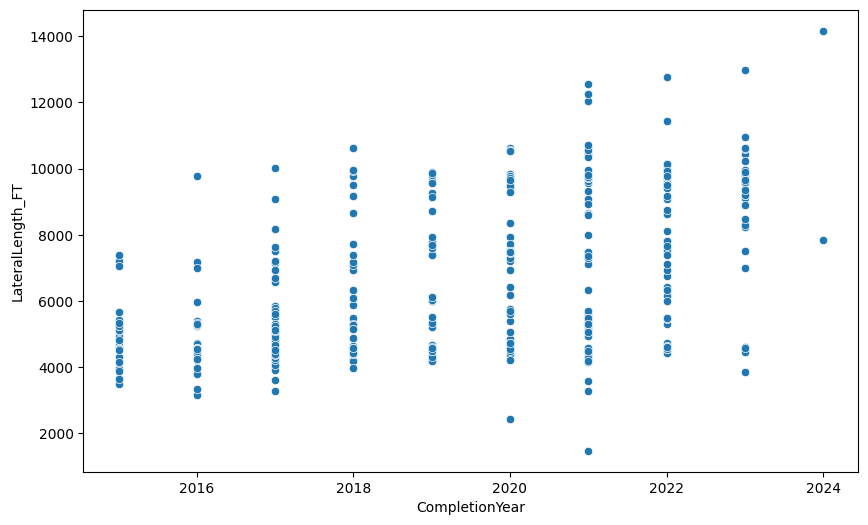

In [0]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='CompletionYear', y='LateralLength_FT', data=df)
plt.show()

In [0]:
set(similar_years)

{(2019, 2024), (2020, 2024), (2021, 2024), (2022, 2024), (2023, 2024)}

# t-test 2

In [0]:
def pairwise_t_tests(df, features, reference_year):
    similar_years = []
    for year1, year2 in combinations(sorted(df[df['CompletionYear'] >= 2019]['CompletionYear'].unique()), 2):
        if year1 == reference_year or year2 == reference_year:
            similar = True  # Assume similarity until proven otherwise for all features
            for feature in features:
                data_year1 = pd.to_numeric(df[df['CompletionYear'] == year1][feature], errors='coerce').dropna()
                data_year2 = pd.to_numeric(df[df['CompletionYear'] == year2][feature], errors='coerce').dropna()

                if len(data_year1) > 0 and len(data_year2) > 0:  # Check for non-empty data
                    t_statistic, p_value = ttest_ind(data_year1, data_year2)
                    if p_value <= 0.05:  # If significant difference found for any feature
                        similar = False
                        break  # No need to check other features if one already indicates a difference
            if similar:
                similar_years.append((year1, year2))
    return similar_years

# Usage
numerical_features = ["Proppant_LBSPerFT", "Fluid_BBLPerFT", "SpacingHzAnyZoneAtDrill"]
similar_years = pairwise_t_tests(df, numerical_features, reference_year)
print("Similar years:", similar_years)


Similar years: [(2019, 2024), (2021, 2024), (2023, 2024)]


# Anova

In [0]:
import pandas as pd
from itertools import combinations
from scipy.stats import f_oneway

def pairwise_anova_tests(df, features):
    similar_years = []
    reference_year = 2019  # Adjust as needed
    for feature in features:
        data = []
        for year in df['CompletionYear'].unique():
            data.append(pd.to_numeric(df[df['CompletionYear'] == year][feature], errors='coerce').dropna())

        # Perform ANOVA
        anova_result = f_oneway(*data)
        print(anova_result)
        print("ANOVA p-value for", feature, ":", anova_result.pvalue)
        
        # If p-value > 0.05, no significant difference found, add all years to similar_years
        if anova_result.pvalue > 0.05:
            similar_years.append(df['CompletionYear'].unique())

    return similar_years

# Usage
numerical_features = ["Proppant_LBSPerFT", "Fluid_BBLPerFT", "SpacingHzAnyZoneAtDrill"]
similar_years = pairwise_anova_tests(df, numerical_features)
print("Similar years:", similar_years)


F_onewayResult(statistic=14.482591828347463, pvalue=5.684672942484126e-14)
ANOVA p-value for Proppant_LBSPerFT : 5.684672942484126e-14
F_onewayResult(statistic=2.7481599285307348, pvalue=0.017572381708949685)
ANOVA p-value for Fluid_BBLPerFT : 0.017572381708949685
F_onewayResult(statistic=3.7942840761855248, pvalue=0.002006753635979373)
ANOVA p-value for SpacingHzAnyZoneAtDrill : 0.002006753635979373
Similar years: []


# Mahalanobis Function

In [0]:
def robust_mahalanobis_method(df, alpha=0.001):
    #Minimum covariance determinant
    rng = np.random.RandomState(0)
    real_cov = np.cov(df.values.T)
    X = rng.multivariate_normal(mean=np.mean(df, axis=0), cov=real_cov, size=506)
    cov = MinCovDet(random_state=0).fit(X)
    mcd = cov.covariance_ #robust covariance metric
    robust_mean = cov.location_  #robust mean
    inv_covmat = sp.linalg.inv(mcd) #inverse covariance metric
    
    #Robust M-Distance
    x_minus_mu = df - robust_mean
    left_term = np.dot(x_minus_mu, inv_covmat)
    mahal = np.dot(left_term, x_minus_mu.T)
    md = np.sqrt(mahal.diagonal())
    
    #Flag as outlier
    outlier = []
    C = np.sqrt(chi2.ppf((1-alpha), df=df.shape[1])) #degrees of freedom = number of variables
    for index, value in enumerate(md):
        if value > C:
            outlier.append(index)
        else:
            continue
    return outlier, md

# Outlier detection with Mahalenobis

In [0]:
import plotly.graph_objects as go
import plotly.express as px

def function(df, year_cutoff, tca):
    df = df[df.tcaID==tca]
    numerical_cols = ["CompletionYear", "LateralLength_FT", "Proppant_LBSPerFT", "Fluid_BBLPerFT", "SpacingHzAnyZoneAtDrill"]
    for col in numerical_cols:
        df[col] = pd.to_numeric(df[col])

    df_nona = df[numerical_cols].dropna()

    df_nona = df_nona[df_nona["CompletionYear"] >= year_cutoff]
    if len(df_nona)>=40:

        min_ll = 3500
        max_ll = (lambda df: max(20000, df["LateralLength_FT"].describe(percentiles=[0.975])["97.5%"]))(df_nona)
        df_nona = df_nona[(df_nona["LateralLength_FT"] >= min_ll) & (df_nona["LateralLength_FT"] <= max_ll)]

        df_nona.reset_index(drop=True, inplace=True)
        print('shape of dataframe :', df_nona.shape)
        outliers, md = robust_mahalanobis_method(df_nona[['Proppant_LBSPerFT', 'Fluid_BBLPerFT', 'SpacingHzAnyZoneAtDrill']], alpha=0.1)

        df_nona['md'] = md
        
        sns.pairplot(df_nona, hue= 'md')
        sns.pairplot(df_nona)
        fig = plt.figure()  # Create a new figure
        df_remain = df_nona[~df_nona.index.isin(outliers)]

        bins = min(30, (len(df_nona))//6)
        bins = max(10, bins)
       
        log_md = np.log(md)
        hist, bin_edges = np.histogram(log_md, bins=bins, density=True)
        bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
        mu, std = norm.fit(np.log(md))

        fig = px.histogram(log_md, nbins=bins, opacity=0.6)

        # Plot the PDF using Plotly Graph Objects
        xmin, xmax = np.min(log_md), np.max(log_md)
        x = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x, mu, std)

        # Add the PDF line to the histogram
        fig.add_trace(go.Scatter(x=x, y=p, mode='lines', line=dict(color='black', width=2)))

        # Update layout with title
        title = f"Fit results for tca: mu = {mu}, std = {std}"
        fig.update_layout(title=title)

        # Show the figure
        fig.show()

        pdf = norm.pdf(bin_centers, mu, std)

        fig1 = go.Figure()
        fig1.add_trace(go.Scatter(x=bin_centers, y=pdf, mode='lines', name='PDF'))
        fig1.add_trace(go.Scatter(x=bin_centers, y=hist, mode='lines', name='Histogram'))
        fig1.show()

        sse = np.sum(np.power(hist - pdf, 2.0))

        # Calculate the R-squared value
        r2 = r2_score(hist, pdf)

        # Calculate the log-likelihood
        log_likelihood = np.sum(norm.logpdf(hist, mu, std))
        print("md after 85 perectile", md[np.log(md) >= norm.ppf(0.85, mu, std)])
        print('sse: ', sse)
        print('r2: ', r2)
        print('Log-Likelihood: ', log_likelihood)
        final_percentile = None
        if r2>=0.95:
            final_percentile = 0.95
        elif r2 <=0.80:
            final_percentile = 0.80
        else:
            x1, y1 = 0.80, 0.80
            x2, y2 = 0.95, 0.95
            slope = (y2 - y1) / (x2 - x1)
            final_percentile = y1 + slope * (r2 - x1)

        
        return df_nona
    
    else:
        return 

In [0]:
df.tcaID.value_counts().tail(35)

HAYNESVILLE_TCA_HSVL_LA EAST_SOUTH               322
HAYNESVILLE_TCA_HSVL_LA CORE_DE SOTO WEST        297
HAYNESVILLE_TCA_HSVL_TX EAST_CORE A WEST         177
HAYNESVILLE_TCA_HSVL_LA NORTH_CADDO CENTRAL      138
HAYNESVILLE_TCA_HSVL_LA CORE_DE SOTO EAST        120
HAYNESVILLE_TCA_HSVL_LA EAST_NORTH               118
HAYNESVILLE_TCA_HSVL_LA CORE_CADDO SOUTH         115
HAYNESVILLE_TCA_HSVL_TX EAST_CORE A NORTH        109
HAYNESVILLE_TCA_HSVL_LA NORTH_CADDO NORTH        101
HAYNESVILLE_TCA_HSVL_LA NFZ_RED RIVER SOUTH       92
HAYNESVILLE_TCA_HSVL_TX DEEP_NORTH                89
HAYNESVILLE_TCA_HSVL_TX EAST_CORE C               87
HAYNESVILLE_TCA_HSVL_TX EAST_CORE A STATELINE     65
HAYNESVILLE_TCA_HSVL_TX EAST_CORE B               61
BOSSIER_TCA_HSVL_LA SOUTH_SABINE                  61
HAYNESVILLE_TCA_HSVL_LA NFZ_NATCHITOCHES          56
BOSSIER_TCA_HSVL_TX DEEP_ SOUTH                   52
BOSSIER_TCA_HSVL_LA NFZ_NATCHITOCHES              51
HAYNESVILLE_TCA_HSVL_TX DEEP_ SOUTH           

/root/.ipykernel/4506/command-3738021254733686-3822159118:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



shape of dataframe : (40, 5)


md after 85 perectile [2.4888407  3.38257584 4.1593369  3.78795724 2.97536386]
sse:  0.9770765033575899
r2:  0.48149208273880084
Log-Likelihood:  -5.913725273340388


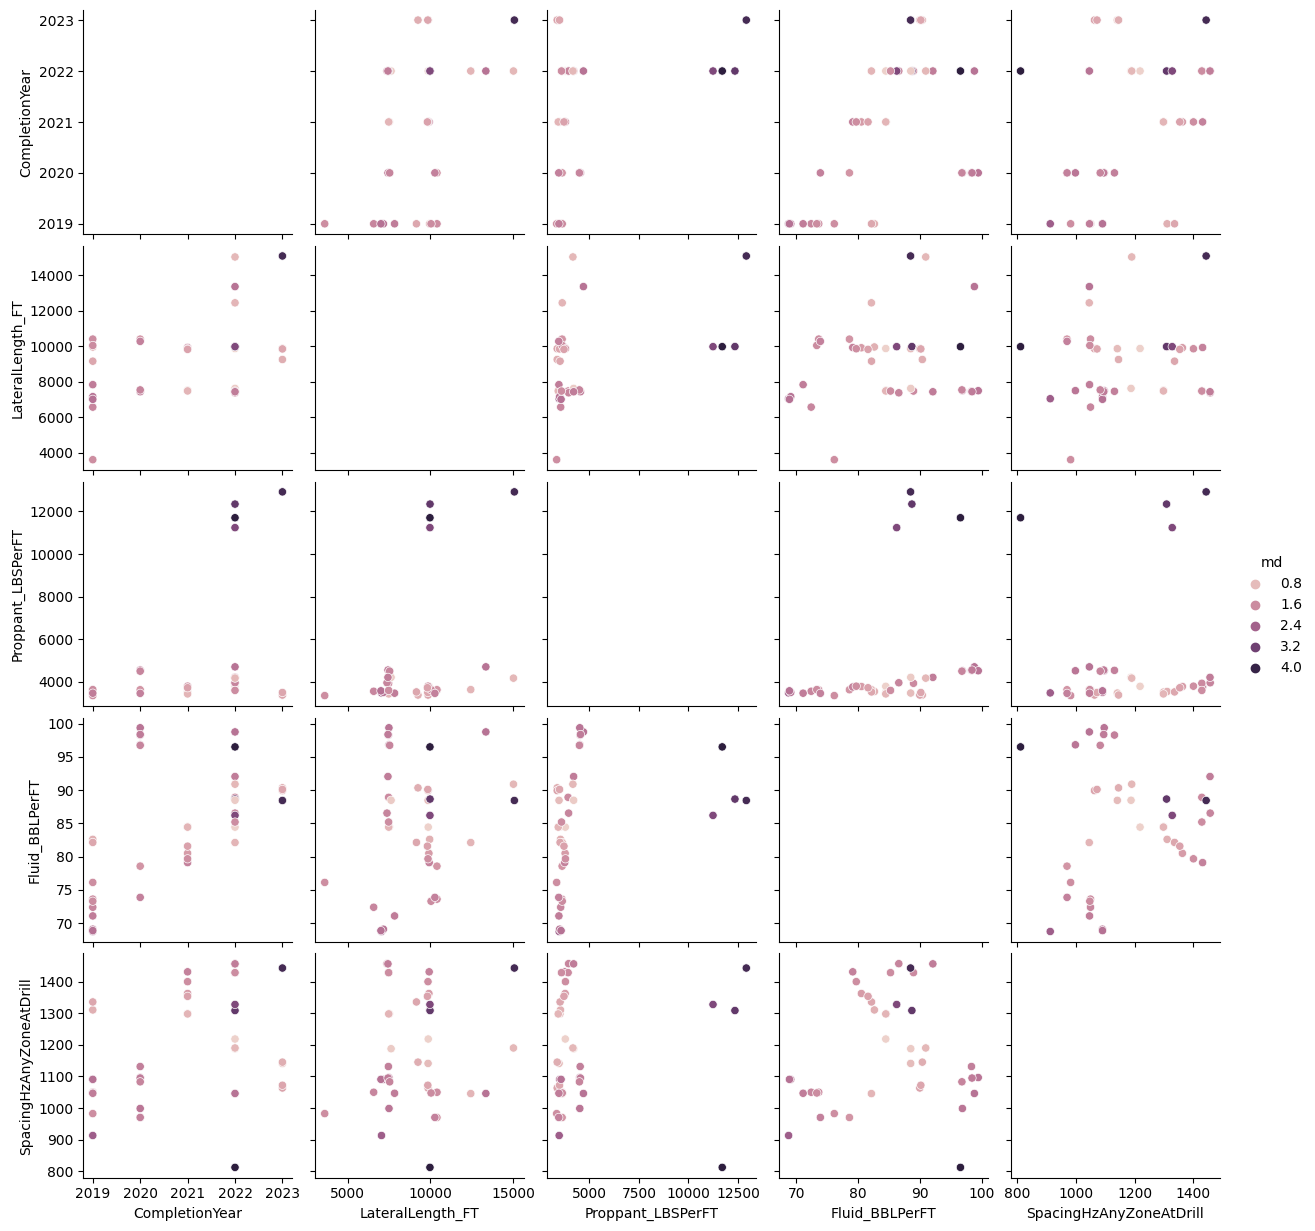

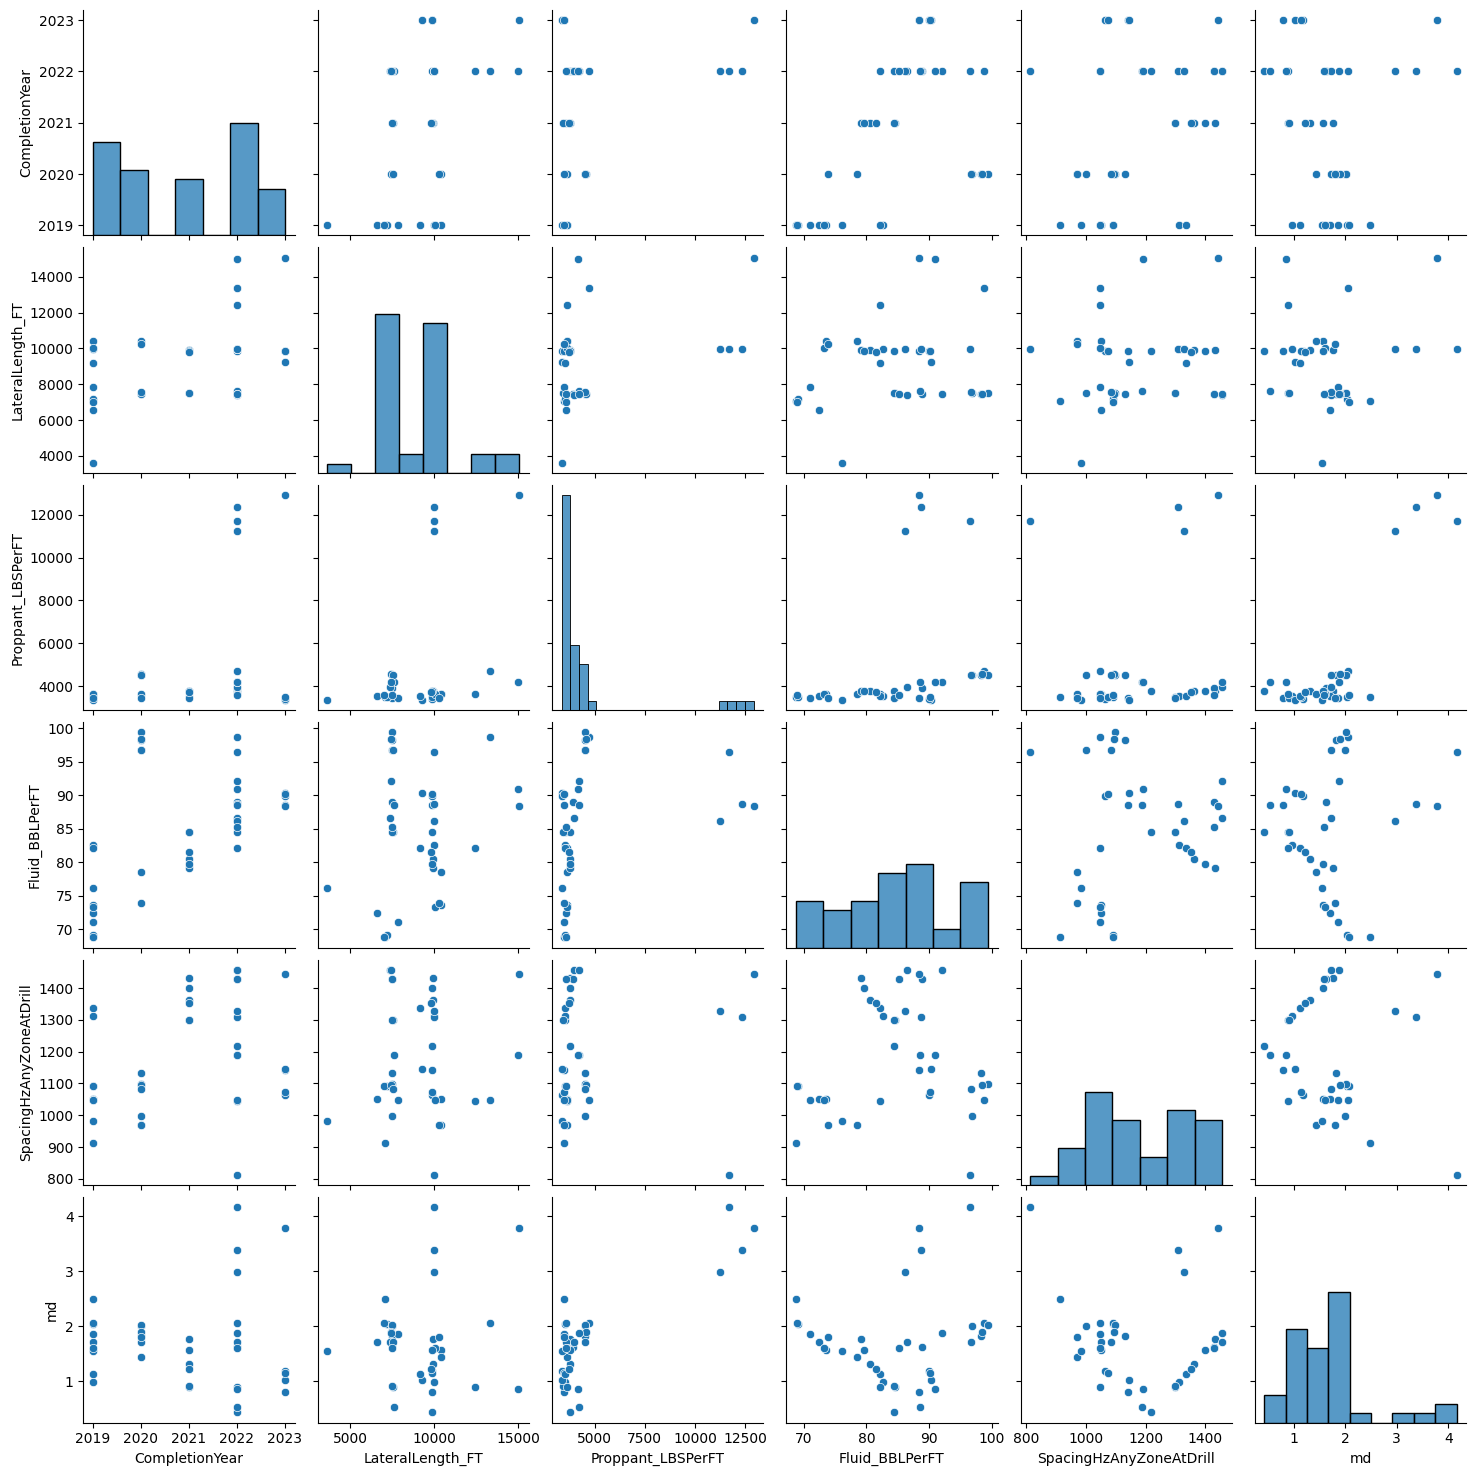

<Figure size 640x480 with 0 Axes>

In [0]:
df11 = function(df, 2019, "BOSSIER_TCA_HSVL_LA SOUTH_SABINE")

In [0]:
# anadarko, 2 flow units  : dataframe in results, list of wells, visuliztion of wells which are in and out.
# gulf coast east, hynsvle:

In [0]:
stop

/root/.ipykernel/4506/command-3738021254733686-3690612781:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



shape of dataframe : (118, 5)


md after 85 perectile [3.37990687 3.40933023 5.46349207 3.0185104  2.83210496 2.56784608
 2.90059853 2.62195525 3.45861746 2.95938623 3.16510817 4.29195461
 3.48332731 6.84682189 2.61972144 2.74284143 3.02210315]
sse:  0.11081404124724474
r2:  0.8866332414933595
Log-Likelihood:  -8.730002204886638


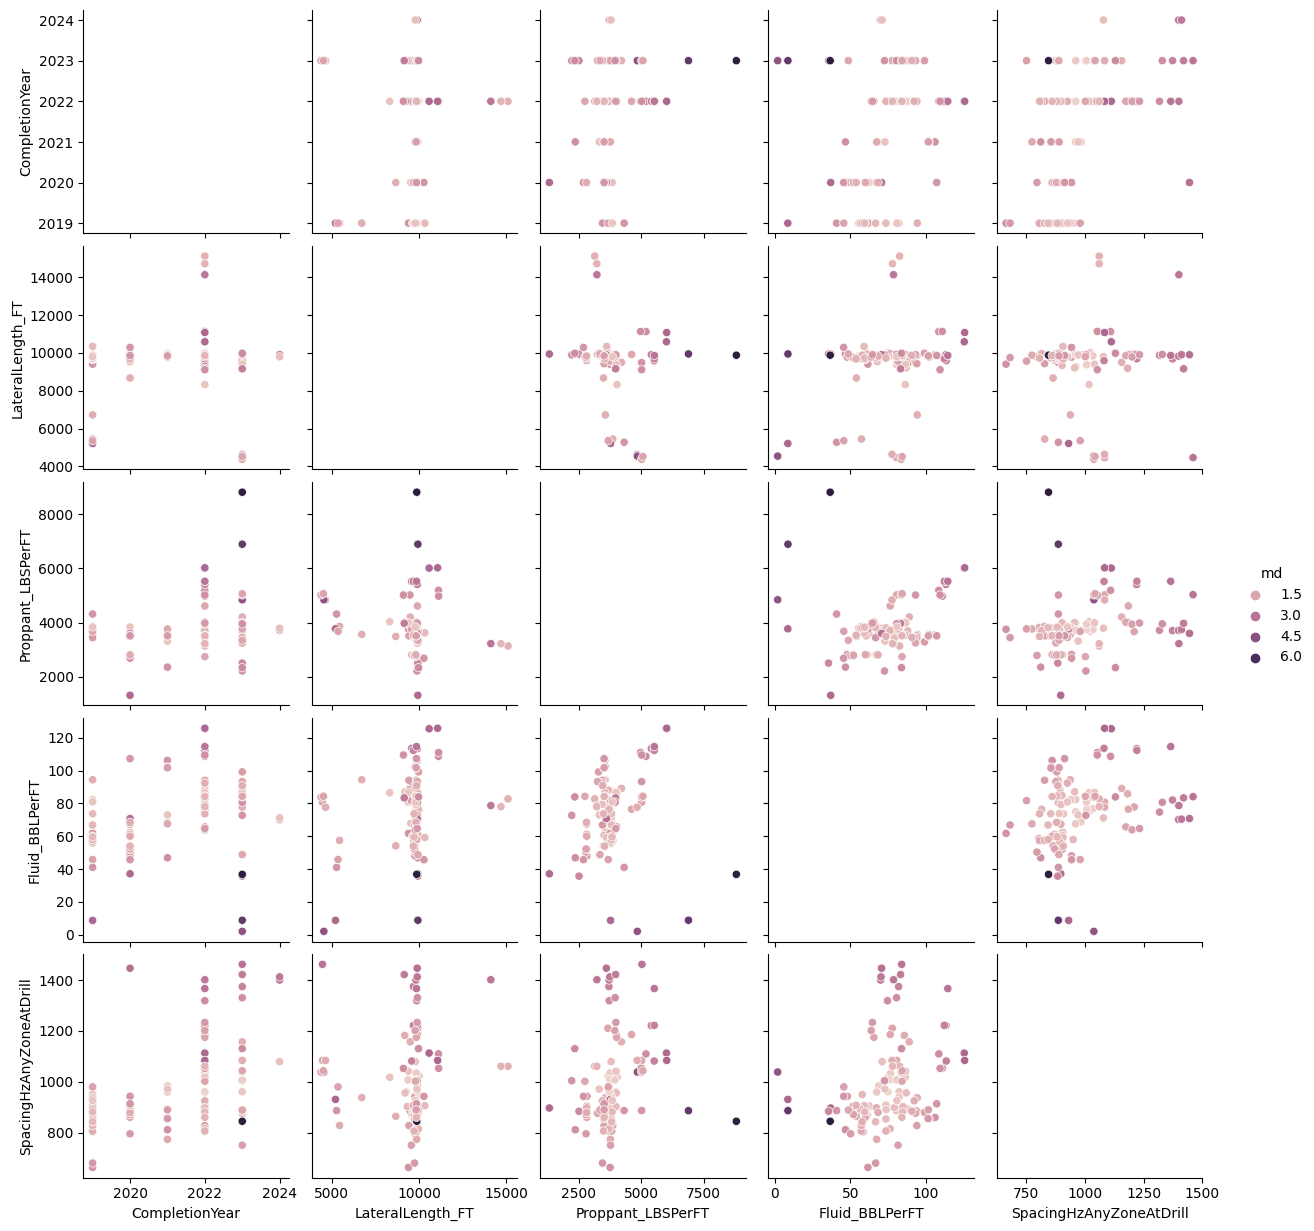

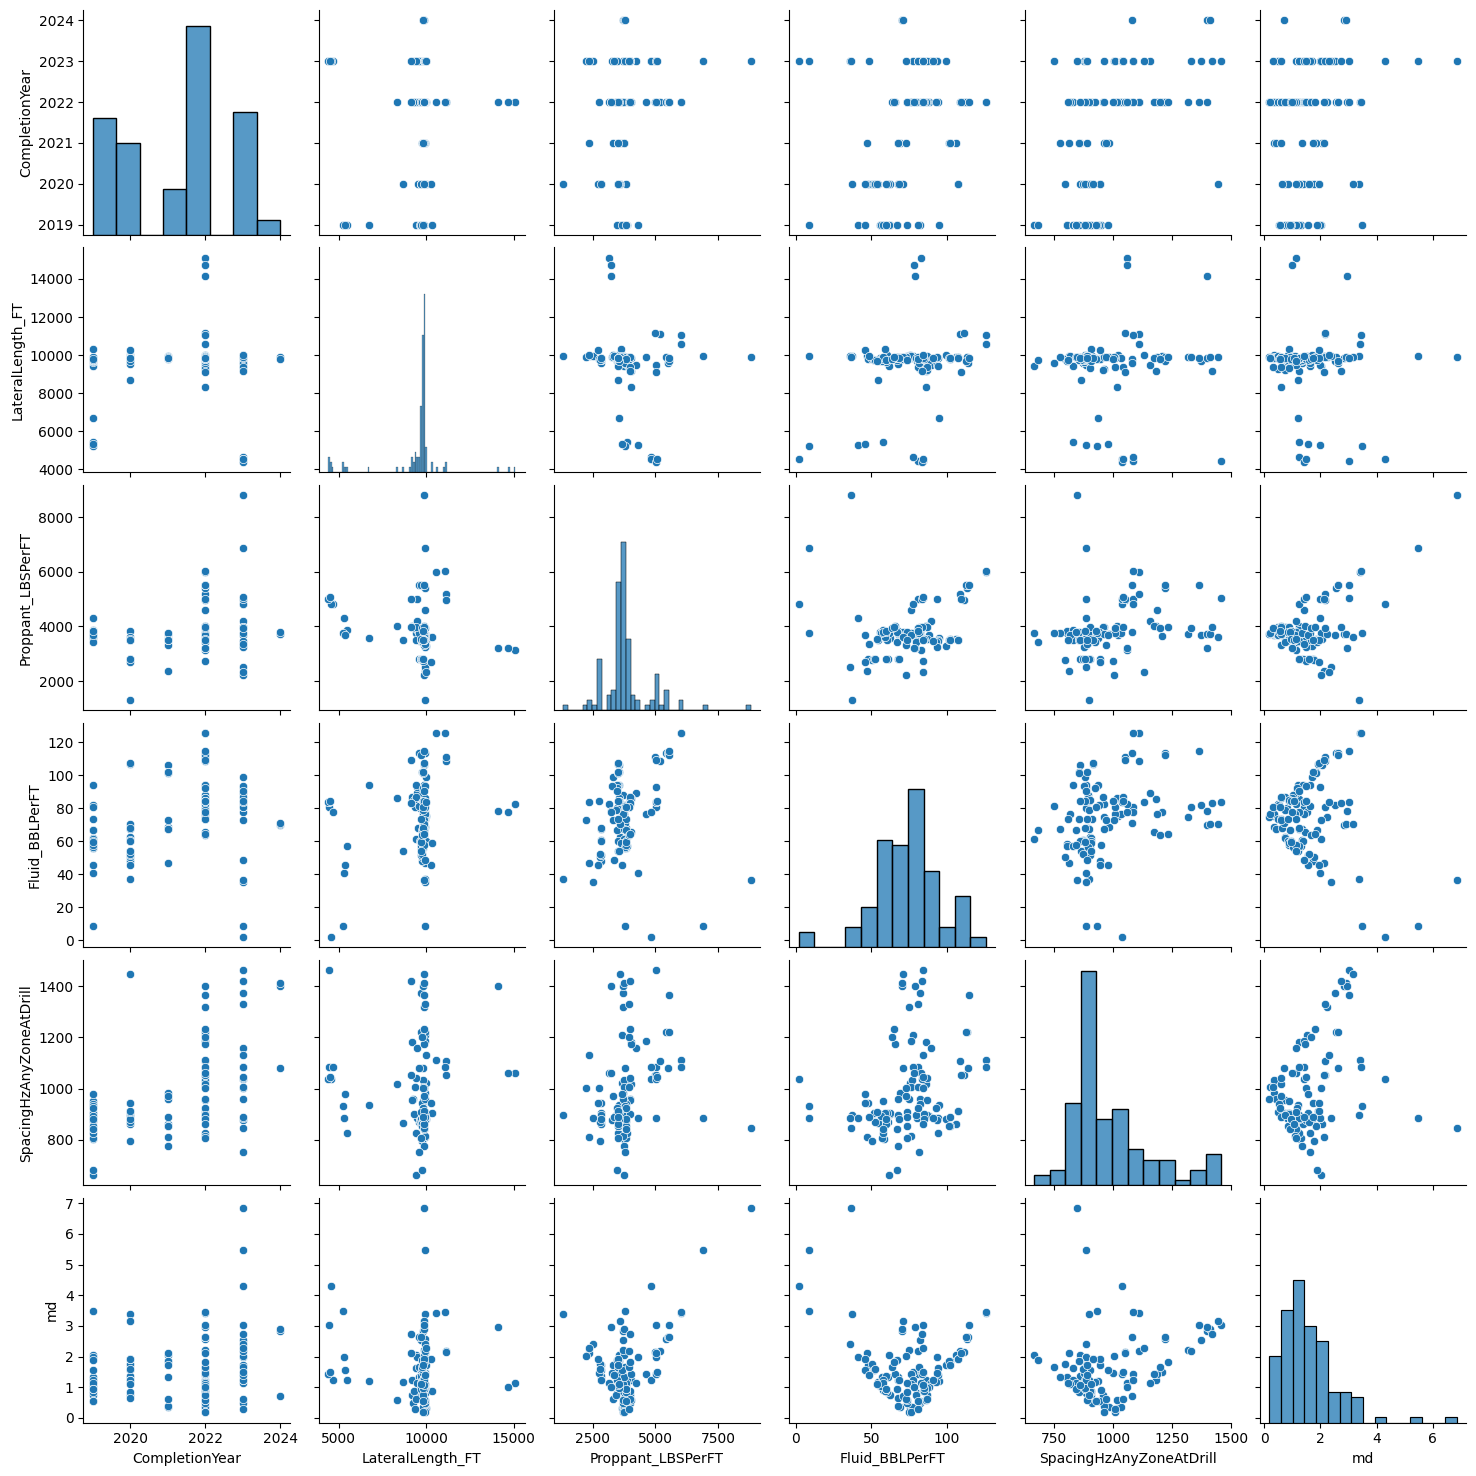

<Figure size 640x480 with 0 Axes>

In [0]:
df11 = function(df, 2019, "BOSSIER_TCA_HSVL_LA SOUTH_SABINE")

shape of dataframe : (61, 5)


/root/.ipykernel/1546/command-3738021254733686-3690612781:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



md after 85 perectile [2.88603952 2.92792039 4.50455959 3.79232061 2.6603404  4.45830052
 2.62032292 5.70404008 2.7880533 ]
sse:  0.03233708860424173
r2:  0.9132607980088727
Log-Likelihood:  -6.248554928658786


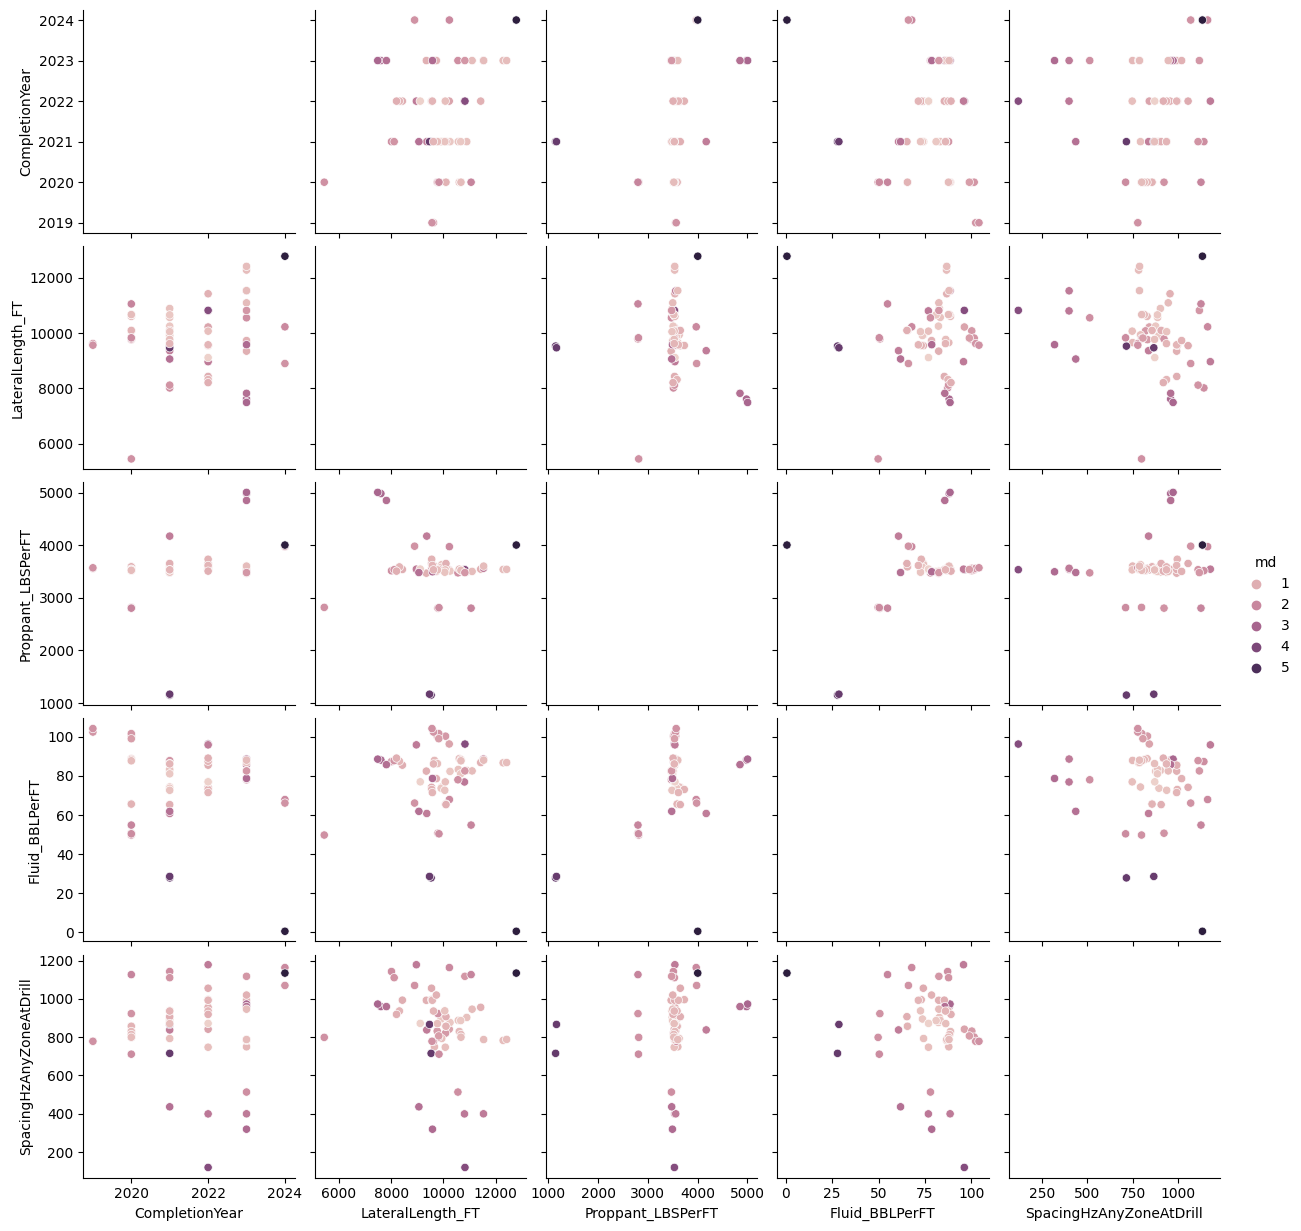

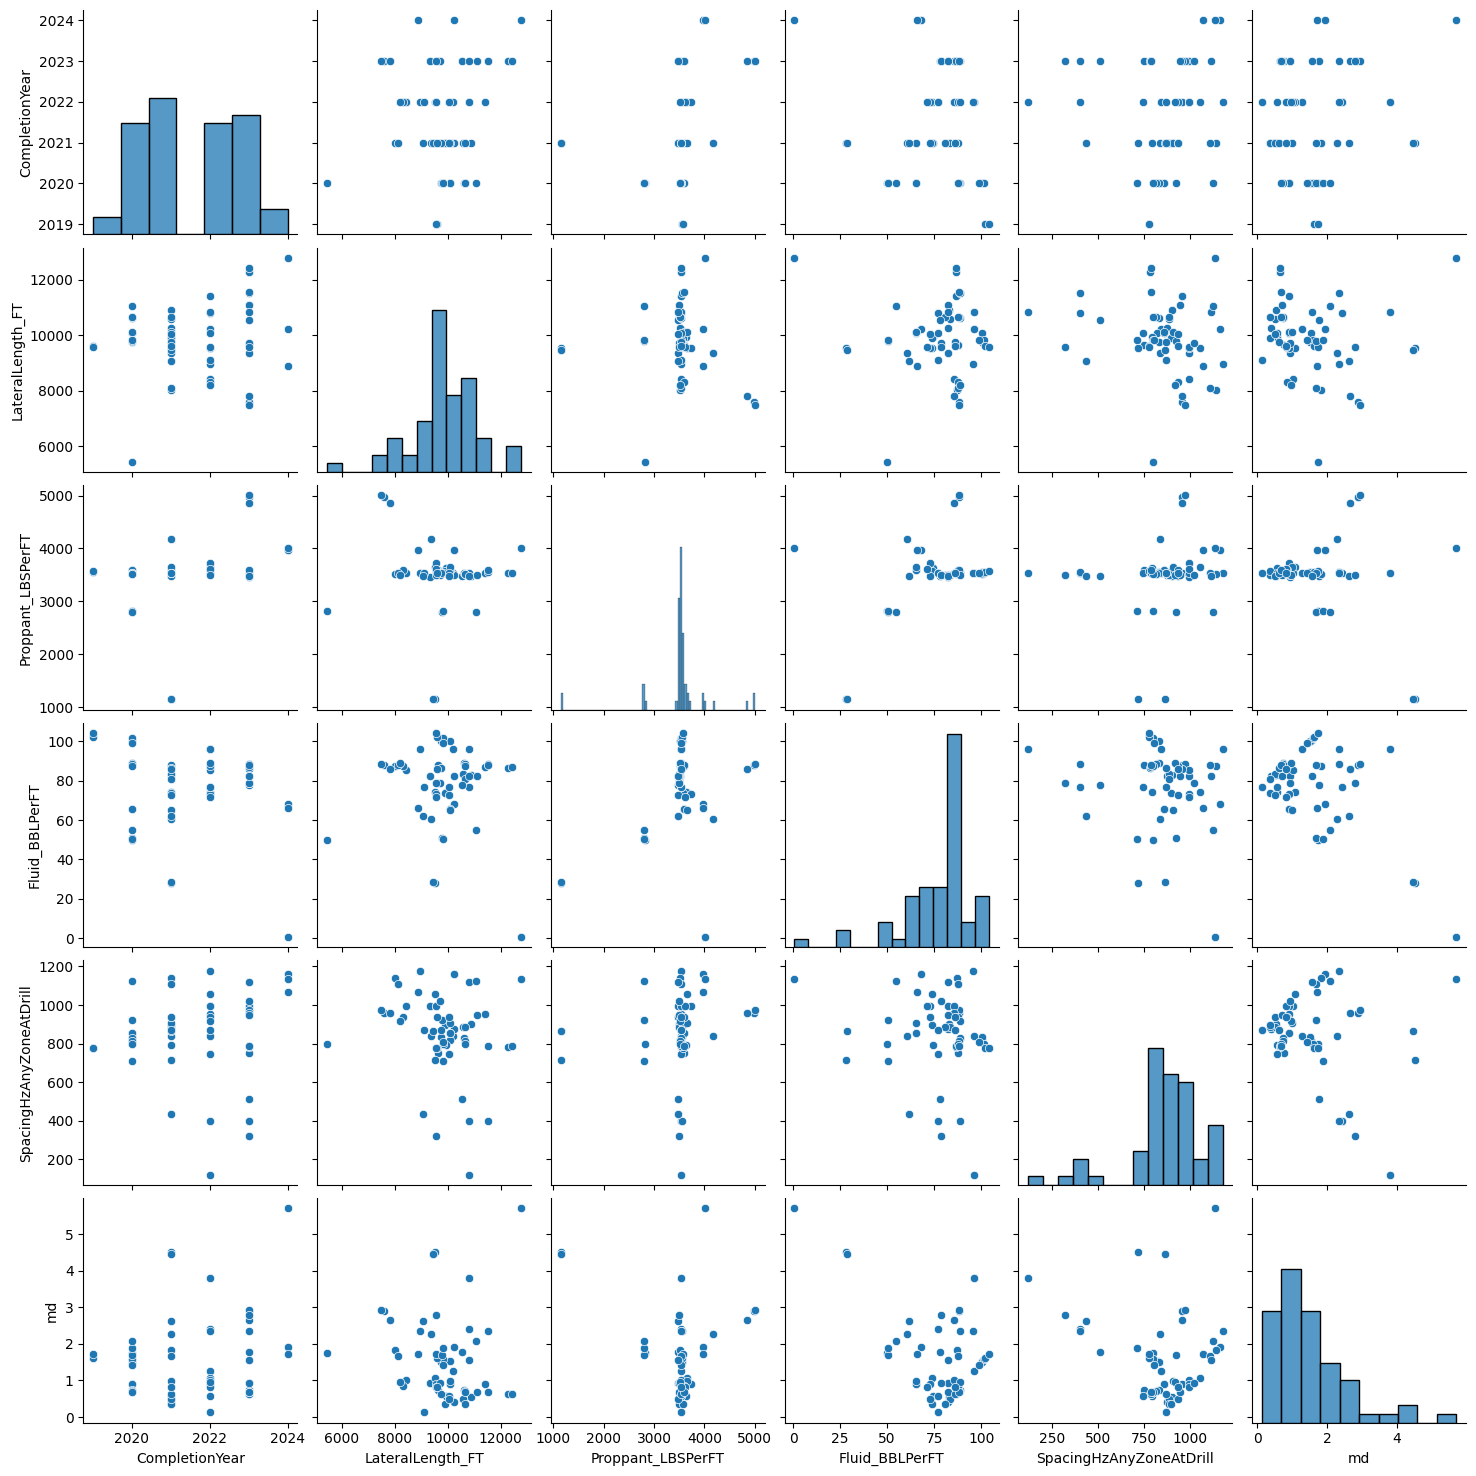

<Figure size 640x480 with 0 Axes>

In [0]:
df11 = function(df, 2019, "HAYNESVILLE_TCA_HSVL_TX EAST_CORE A STATELINE")

In [0]:
df11 = function(df, 2019, "HAYNESVILLE_TCA_HSVL_TX EAST_CORE A STATELINE")

/root/.ipykernel/5817/command-3738021254733686-2268776532:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



shape of dataframe : (61, 5)
hist [ 1  0  3  5 12 10 13 10  4  3]


[ 1  0  3  5 12 10 13 10  4  3]
[0.00907488 0.03646906 0.11018399 0.25027798 0.42740248 0.54873379
 0.52965934 0.38436322 0.20969944 0.08601278]


md after 85 perectile [2.33778157 3.79232061 5.70404008 2.92792039 2.41301149 2.27901996
 4.50455959 2.62032292 2.7880533  2.34249224 2.88603952 2.6603404
 4.45830052]
sse:  525.9731715363346
r2:  -1.6180844775327756
Log-Likelihood:  -549.7926553352429


<Figure size 640x480 with 0 Axes>

shape of dataframe : (61, 5)


/root/.ipykernel/1533/command-2237708908245750-742675964:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



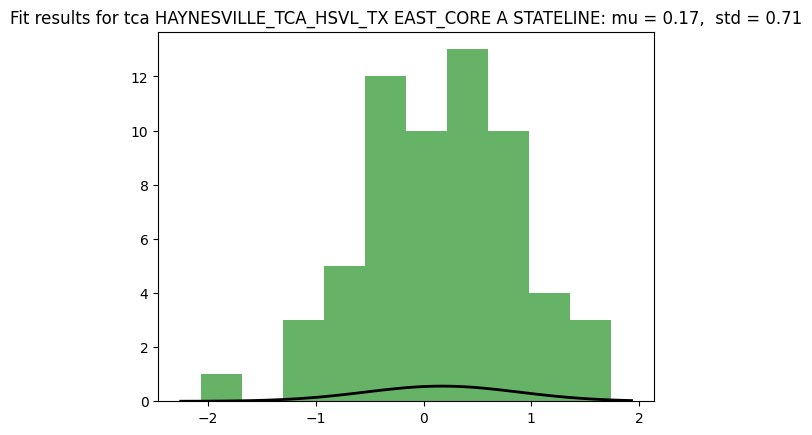

[0.04307773 0.         0.12923318 0.21538863 0.51693272 0.43077727
 0.56001045 0.43077727 0.17231091 0.12923318]
[0.00907488 0.03646906 0.11018399 0.25027798 0.42740248 0.54873379
 0.52965934 0.38436322 0.20969944 0.08601278]


md after 85 perectile [2.33778157 3.79232061 5.70404008 2.92792039 2.41301149 2.27901996
 4.50455959 2.62032292 2.7880533  2.34249224 2.88603952 2.6603404
 4.45830052]
sse:  0.03233708860424158
r2:  0.9132607980088732
Log-Likelihood:  -6.248554928658786


In [0]:
df11 = function(df, 2019, "HAYNESVILLE_TCA_HSVL_TX EAST_CORE A STATELINE")

In [0]:
all_tca = df.tcaID.unique()

In [0]:
def function2(df, year_cutoff, tca):
    df = df[df.tcaID == tca]
    numerical_cols = ["CompletionYear", "LateralLength_FT", "Proppant_LBSPerFT", "Fluid_BBLPerFT", "SpacingHzAnyZoneAtDrill"]
    
    for col in numerical_cols:
        df[col] = pd.to_numeric(df[col])

    df_nona = df[numerical_cols].dropna()
    df_nona = df_nona[df_nona["CompletionYear"] >= year_cutoff]
    
    if len(df_nona) >= 40:
        min_ll = 3500
        max_ll = max(20000, df_nona["LateralLength_FT"].describe(percentiles=[0.975])["97.5%"])
        df_nona = df_nona[(df_nona["LateralLength_FT"] >= min_ll) & (df_nona["LateralLength_FT"] <= max_ll)]
        df_nona.reset_index(drop=True, inplace=True)
        print('Shape of dataframe pca:', df_nona.shape)
        
        outliers, md = robust_mahalanobis_method(df_nona[['Proppant_LBSPerFT', 'Fluid_BBLPerFT', 'SpacingHzAnyZoneAtDrill']], alpha=0.1)
        percentiles = [0.99, 0.98, 0.95, 0.90, 0.85, 0.80, 0.75, 0.70, 0.65, 0.60]
        
        mu_global, std_global = norm.fit(np.log(md))
        print(f'----->For the typecurve area {tca}<-----')
        
        max_r2 = -float('inf')  # Initialize max_r2
        SSE = -float('inf')
        best_percentile = 0
        LOG_likelihood = 0
        len_of_md = len(md)
        for percentile in percentiles:
            md1 = md[np.log(md) <= norm.ppf(percentile, mu_global, std_global)]
            
            mu, std = norm.fit(np.log(md1))
            
            logmd1 = np.log(md1)
            hist, bin_edges = np.histogram(logmd1, bins=30, density=True)
            bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
            pdf = norm.pdf(bin_centers, mu, std)
            sse = np.sum(np.power(hist - pdf, 2.0))
            
            # Calculate the R-squared value
            r2 = r2_score(hist, pdf)
            
            # Calculate the log-likelihood
            log_likelihood = np.sum(norm.logpdf(hist, mu, std))
            
            if r2 > max_r2:
                max_r2 = r2
                best_percentile = percentile
                SSE = sse
                LOG_likelihood = log_likelihood
                len_of_md = len(md1)
        print(f"Length of md: {len_of_md} at percentile: {best_percentile}")
        print(f'SSE at percentile {best_percentile}: {SSE}')
        print(f'R2 at percentile {best_percentile}: {max_r2}')
        print(f'Log-Likelihood at percentile {best_percentile}: {LOG_likelihood}')
        print('-------------------------------------------------------')
    else:
        return


In [0]:
for tca in all_tca:
    function2(df, 2019, tca)

/root/.ipykernel/5817/command-3920902361360253-4240947390:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Shape of dataframe pca: (87, 5)
----->For the typecurve area HAYNESVILLE_TCA_HSVL_LA CORE_CADDO SOUTH<-----
Length of md: 85 at percentile: 0.99
SSE at percentile 0.99: 2.088489420082037
R2 at percentile 0.99: 0.5496943071294333
Log-Likelihood at percentile 0.99: -16.694649105186635
-------------------------------------------------------
Shape of dataframe pca: (117, 5)


/root/.ipykernel/5817/command-3920902361360253-4240947390:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



----->For the typecurve area HAYNESVILLE_TCA_HSVL_LA NORTH_CADDO CENTRAL<-----
Length of md: 116 at percentile: 0.99
SSE at percentile 0.99: 0.4083599697291481
R2 at percentile 0.99: 0.7984489207806376
Log-Likelihood at percentile 0.99: -16.075729952104684
-------------------------------------------------------
Shape of dataframe pca: (243, 5)


/root/.ipykernel/5817/command-3920902361360253-4240947390:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



...

/root/.ipykernel/5817/command-3920902361360253-4240947390:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



----->For the typecurve area HAYNESVILLE_TCA_HSVL_TX EAST_CORE A STATELINE<-----
Length of md: 33 at percentile: 0.6
SSE at percentile 0.6: 4.051345779126416
R2 at percentile 0.6: 0.5139999604505294
Log-Likelihood at percentile 0.6: -72.02719698196776
-------------------------------------------------------
Shape of dataframe pca: (53, 5)


/root/.ipykernel/5817/command-3920902361360253-4240947390:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/root/.ipykernel/5817/command-3920902361360253-4240947390:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



----->For the typecurve area HAYNESVILLE_TCA_HSVL_TX EAST_CORE B<-----
Length of md: 53 at percentile: 0.99
SSE at percentile 0.99: 3.4809204722533584
R2 at percentile 0.99: 0.2195115590288077
Log-Likelihood at percentile 0.99: -17.511801330608463
-------------------------------------------------------


/root/.ipykernel/5817/command-3920902361360253-4240947390:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/root/.ipykernel/5817/command-3920902361360253-4240947390:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/root/.ipykernel/5817/command-3920902361360253-4240947390:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user

shape of dataframe pca : (61, 5)


/root/.ipykernel/13626/command-2237708908245750-1913303491:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



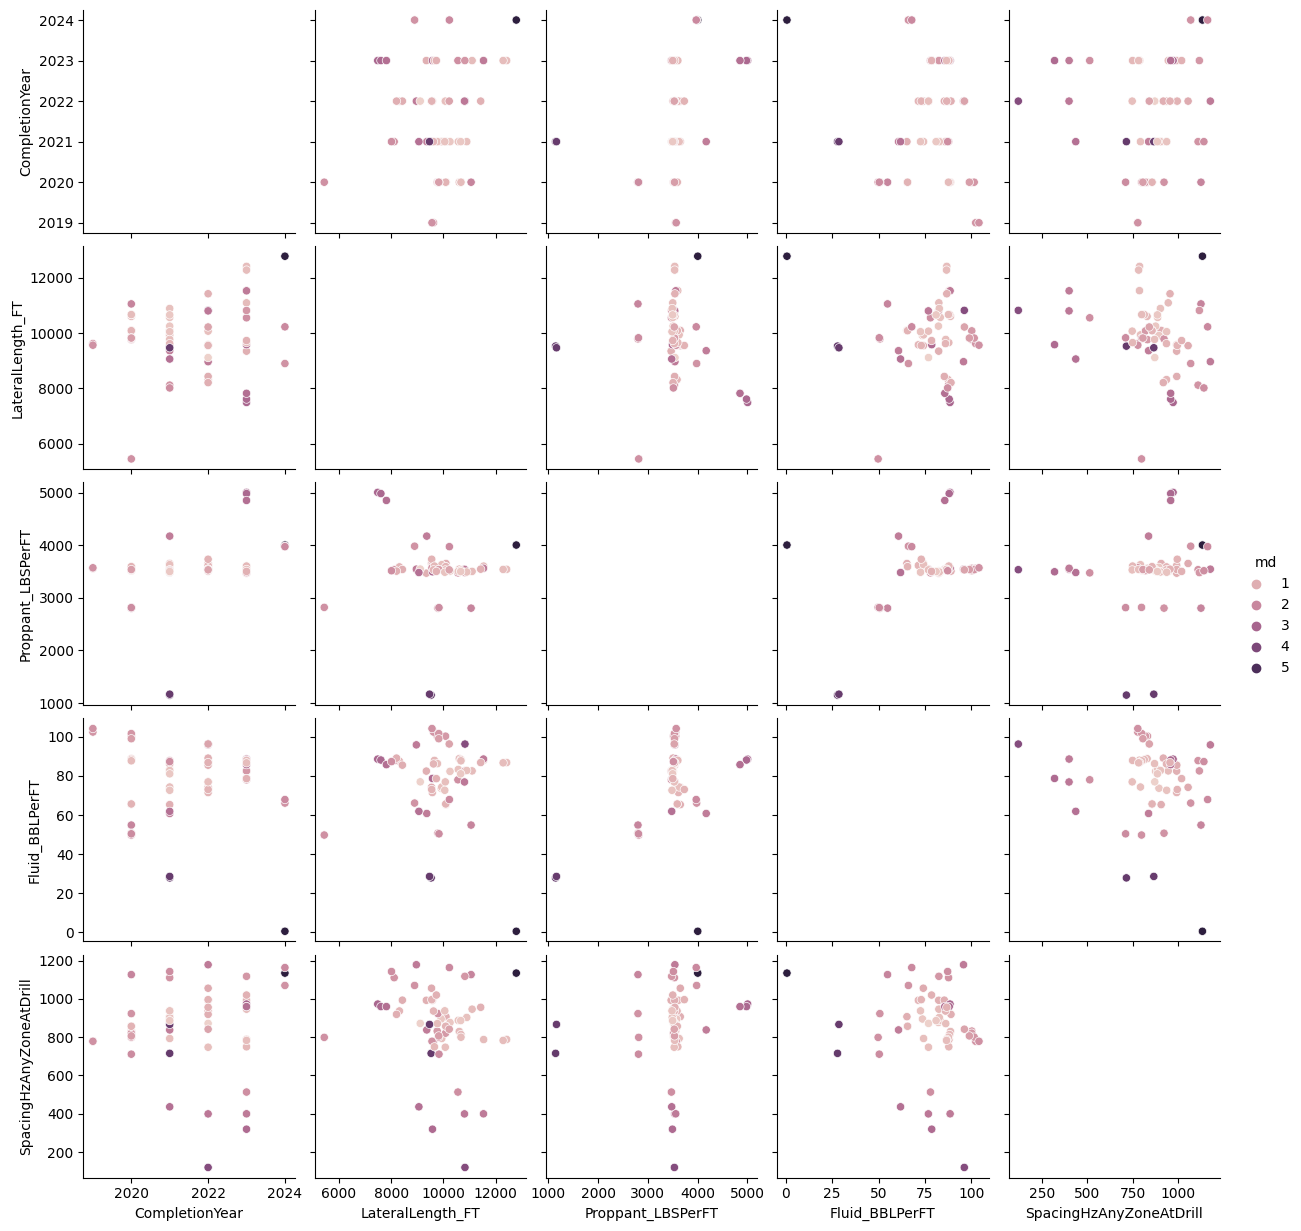

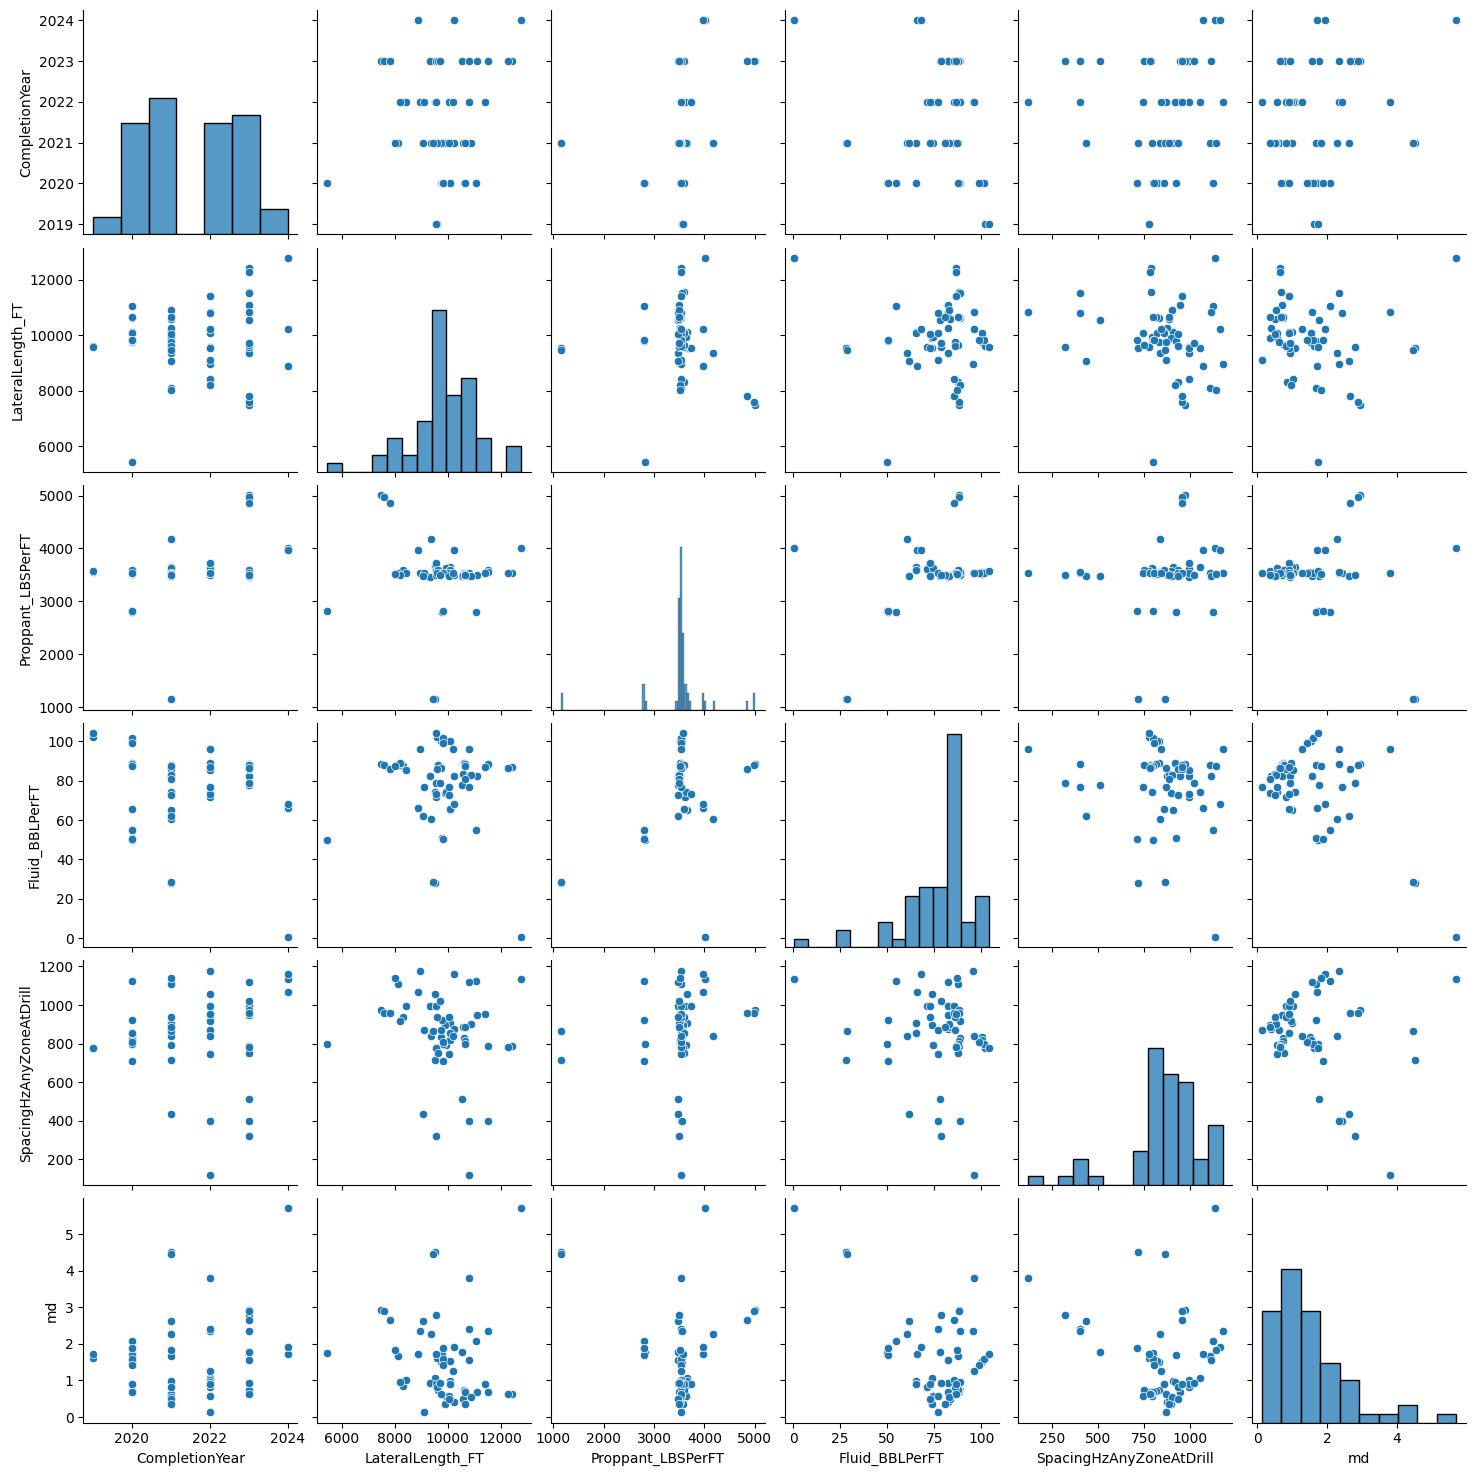

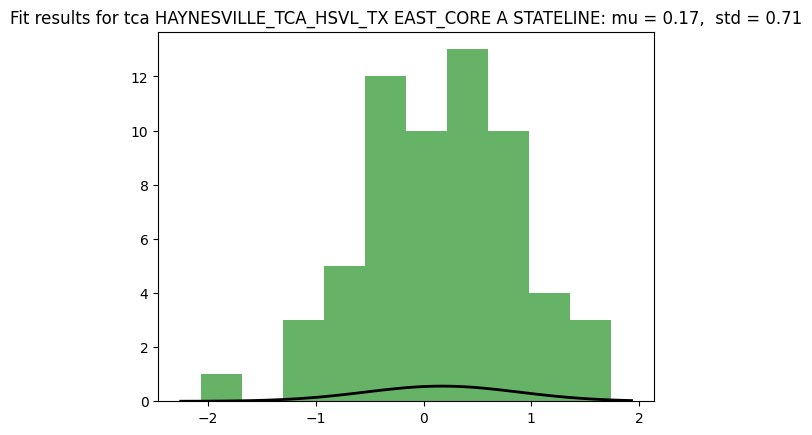

md after 85 perectile [2.33778157 3.79232061 5.70404008 2.92792039 2.41301149 2.27901996
 4.50455959 2.62032292 2.7880533  2.34249224 2.88603952 2.6603404
 4.45830052]
sse:  0.03233708860424158
r2:  0.9132607980088732
Log-Likelihood:  -6.248554928658786


In [0]:
df11 = function(df, 2019, "HAYNESVILLE_TCA_HSVL_TX EAST_CORE A STATELINE")

In [0]:
import plotly.express as px
fig = px.scatter(df, x='SpacingHzAnyZoneAtDrill', y='md')
fig.show()

In [0]:
for tca in all_tca:
    function(df, 2019, tca)

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-3920902361360189>, line 1
----> 1 stop

NameError: name 'stop' is not defined

In [0]:
function(df, 2020)

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-3920902361360189>, line 1
----> 1 stop

NameError: name 'stop' is not defined

In [0]:
function(df, 2021)

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-3920902361360189>, line 1
----> 1 stop

NameError: name 'stop' is not defined

In [0]:
function(df, 2022)

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-3920902361360189>, line 1
----> 1 stop

NameError: name 'stop' is not defined

In [0]:
function(df, 2023)

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-3920902361360189>, line 1
----> 1 stop

NameError: name 'stop' is not defined

In [0]:
def mahalanobus_with_pca(df, year_cutoff):

    numerical_cols = ["CompletionYear","LateralLength_FT","Proppant_LBSPerFT","Fluid_BBLPerFT", "SpacingHzAnyZoneAtDrill"] 
    for col in numerical_cols:
        df[col] = pd.to_numeric(df[col])

    df_nona = df[numerical_cols].dropna()
    
    df_nona = df_nona[df_nona["CompletionYear"]>=year_cutoff]

    min_ll = 3500
    max_ll = (lambda df: max(20000, df["LateralLength_FT"].describe(percentiles=[0.975])["97.5%"]))(df_nona)
    df_nona = df_nona[(df_nona["LateralLength_FT"]>=min_ll) & (df_nona["LateralLength_FT"]<=max_ll)]
    

    df_array = df_nona.values
    df_array = df_array[:,1:] # for now, taking out the completion year
    numerical_cols = numerical_cols[1:]

    #Scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_array)

    # PCA 
    pca = PCA(n_components=len(numerical_cols))
    X_pca = pca.fit_transform(X_scaled)

    df_nona.reset_index(drop=True, inplace=True)

    n_components = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
    print(f"Number of components to explain 95% variance: {n_components}")
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)

    pca_columns = [f'PCA{i}' for i in range (1, n_components+1)]

    df_pca = pd.DataFrame(X_pca, columns=pca_columns)
    print('shape of dataframe pca :', df_pca.shape)

    df_pca.reset_index(drop=True, inplace=True)

    outliers, md = robust_mahalanobis_method(df_pca[pca_columns], alpha = 0.1)
    

    df_pca['md']= md
    df_remain = df_pca[~df_pca.index.isin(outliers)]

    logmd = np.log(md)
    hist, bin_edges = np.histogram(logmd, bins=30, density=True)
    bin_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])
    mu, std = norm.fit(np.log(md))

    plt.hist(np.log(md), bins=30, density=True, alpha=0.6, color='g')

    # Plot the PDF
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    plt.plot(x, p, 'k', linewidth=2)
    title = "Fit results: mu = %.2f,  std = %.2f" % (mu, std)
    plt.title(title)

    plt.show()

    pdf = norm.pdf(bin_centers, mu, std)
    sse = np.sum(np.power(hist - pdf, 2.0))

    # Calculate the R-squared value
    r2 = r2_score(hist, pdf)

    # Calculate the log-likelihood
    log_likelihood = np.sum(norm.logpdf(hist, mu, std))

    print('sse: ', sse)
    print('r2: ', r2)
    print('Log-Likelihood: ', log_likelihood)

    

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-3920902361360189>, line 1
----> 1 stop

NameError: name 'stop' is not defined

In [0]:
mahalanobus_with_pca(df, 2019)

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-3920902361360189>, line 1
----> 1 stop

NameError: name 'stop' is not defined

In [0]:
sse:  0.24703080527505866
r2:  0.8445982046462913
Log-Likelihood:  -17.928014530055908

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-3920902361360189>, line 1
----> 1 stop

NameError: name 'stop' is not defined